In [1]:
import pandas as pd
import plotly.express as px


In [23]:
indiceDeRezagoSocial2000 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2000.xlsx',
    usecols=['Entidad federativa','Índice de rezago social'],
    skiprows=4,
    header=0
)
indiceDeRezagoSocial2005 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2005.xlsx',
    usecols=['Índice de rezago social'],
    skiprows=4,
    header=0
)
indiceDeRezagoSocial2010 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2010.xlsx',
    usecols=['Índice de rezago social'],
    skiprows=4,
    header=0
)
indiceDeRezagoSocial2015 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2015.xlsx',
    usecols=['Índice de rezago social'],
    skiprows=4,
    header=0
)
indiceDeRezagoSocial2020 = pd.read_excel(
    '../data/IndiceDeRezagoSocial/IRS_entidades_mpios_2020.xlsx',
    usecols=['Índice de rezago social'],
    skiprows=4,
    header=0
)

indiceDeRezagoSocial2000_2020=pd.concat([
    indiceDeRezagoSocial2000.reset_index(drop=True),
    indiceDeRezagoSocial2005.reset_index(drop=True),
    indiceDeRezagoSocial2010.reset_index(drop=True),
    indiceDeRezagoSocial2015.reset_index(drop=True),
    indiceDeRezagoSocial2020.reset_index(drop=True)
], axis=1)
indiceDeRezagoSocial2000_2020=indiceDeRezagoSocial2000_2020.drop([0,1,34,35,36,37,38])
indiceDeRezagoSocial2000_2020.columns = ['Entidad', '2000', '2005', '2010', '2015', '2020']
indiceDeRezagoSocial2000_2020

,Entidad,2000,2005,2010,2015,2020
2,Aguascalientes,-1.135999,-1.144505,-1.106007,-1.036695,-1.101561
3,Baja California,-1.028277,-0.663637,-0.855111,-0.818078,-0.642387
4,Baja California Sur,-0.710752,-0.481994,-0.473796,-0.395355,-0.317027
5,Campeche,0.534566,0.324935,0.216209,0.304117,0.244535
6,Coahuila,-1.266207,-1.250579,-1.160584,-1.064973,-1.147587
7,Colima,-0.708163,-0.756951,-0.803184,-0.657650,-0.690655
8,Chiapas,2.267370,2.548142,2.271180,2.387669,2.644224
9,Chihuahua,-0.738870,-0.606449,-0.499152,-0.587185,-0.518357
10,Distrito Federal,-1.509716,-1.396498,-1.283248,-1.313332,-1.115345
11,Durango,-0.142996,-0.241208,-0.008311,-0.032549,-0.045956


Datos transformados:
               Entidad   Año  Porcentaje
0       Aguascalientes  2000   -1.135999
1      Baja California  2000   -1.028277
2  Baja California Sur  2000   -0.710752
3             Campeche  2000    0.534566
4             Coahuila  2000   -1.266207

Años disponibles: [np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020)]
Entidades: 32


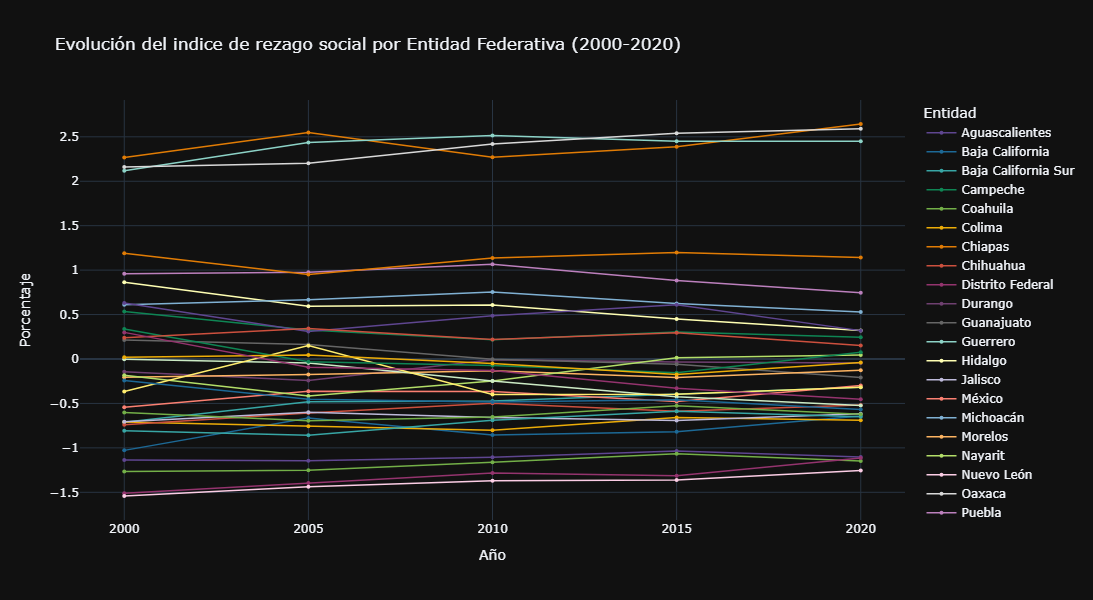

In [24]:
columna_entidad = indiceDeRezagoSocial2000_2020.columns[0]  
colores = px.colors.qualitative.Prism + px.colors.qualitative.Set3
df_tidy = pd.melt(
    indiceDeRezagoSocial2000_2020,  
    id_vars=[columna_entidad],
    var_name='Año', 
    value_name='Porcentaje'
)
df_tidy['Año'] = df_tidy['Año'].astype(int)

# Verificar que funcionó
print("Datos transformados:")
print(df_tidy.head())
print(f"\nAños disponibles: {sorted(df_tidy['Año'].unique())}")
print(f"Entidades: {df_tidy['Entidad'].nunique()}")

# Crear gráfico de líneas
fig = px.line(
    df_tidy, 
    x='Año', 
    y='Porcentaje', 
    color='Entidad',
    color_discrete_sequence=colores,
    title='Evolución del indice de rezago social por Entidad Federativa (2000-2020)',
    labels={'Indice': 'Indice de rezago social', 'Año': 'Año'},
    template='plotly_dark'
)

# Mejorar visualización
fig.update_traces(mode='lines+markers', marker=dict(size=4), line=dict(width=1.5))
fig.update_layout(
    height=600,
    hovermode='x unified',
    legend=dict(
        title='Entidad',
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)

# Mostrar gráfica
fig.show()

# Guardar como HTML interactivo
fig.write_html('indice_de_rezago_social.html')

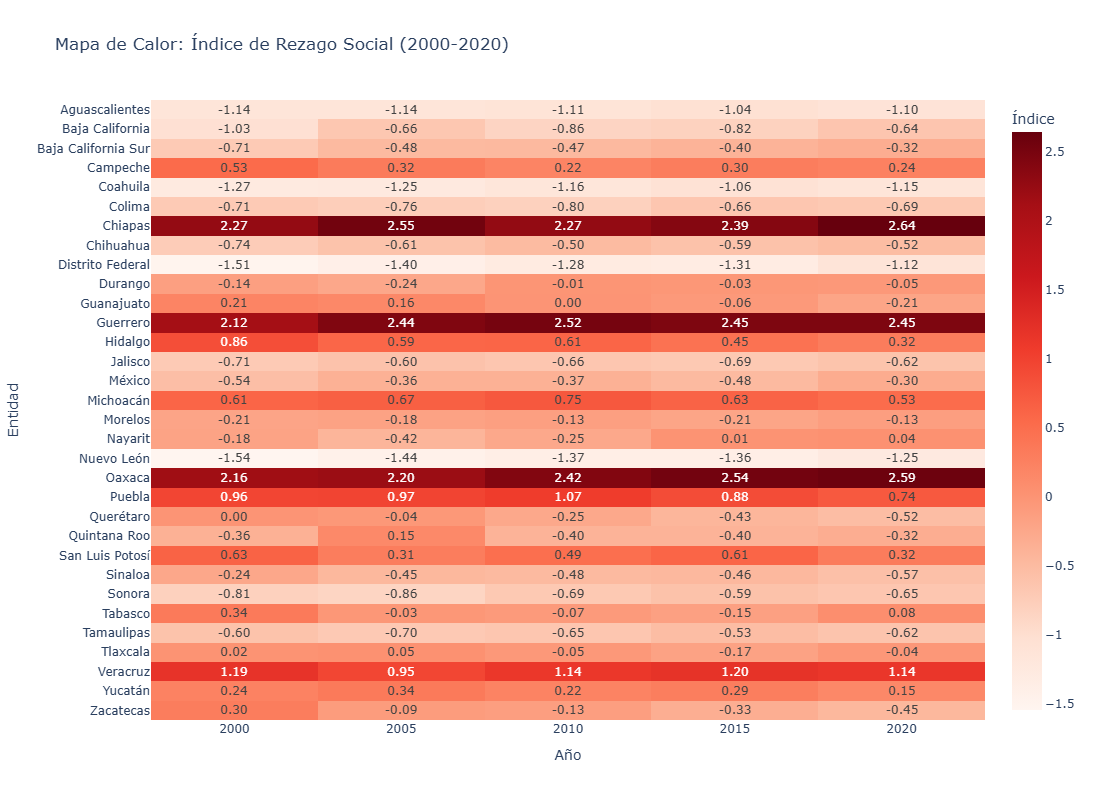

In [25]:
matriz = indiceDeRezagoSocial2000_2020.set_index('Entidad')
fig = px.imshow(
    matriz,
    text_auto='.2f',
    aspect='auto',
    title='Mapa de Calor: Índice de Rezago Social (2000-2020)',
    labels=dict(x='Año', y='Entidad', color='Índice'),
    color_continuous_scale='Reds',
    template='plotly_white'
)
fig.update_layout(height=800)
fig.write_html('mapa_calor_rezago_social.html')
fig.show()